# Feature extraction
Emanuel de Jong (495804) - Erik Markvoort (519894)

## Imports

In [1]:
import os
import pickle
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from skimage import io, morphology, measure

## Helper functions

#### The image display function from the week 3 lab session.

In [2]:
def display(np_image):
    """
    This is a display function that we have added to show numpy images at full size
    If you pass in an image with 3 channels, it will be displayed in RGB
    If you passn in an image with 1 channel, it will be displayed in grayscale
    """
    dpi = matplotlib.rcParams['figure.dpi']
    if len(np_image.shape) == 3:
        height, width, depth = np_image.shape
    else:
        height, width = np_image.shape

    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)

    # Create a figure of the right size with one axis that takes up the full figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')
    
    # Display the image in either RGB or grayscale (depending on the amount of dimensions)
    if (len(np_image.shape) >= 3):
        ax.imshow(np_image)
    else:
        ax.imshow(np_image, cmap='gray')

    plt.show()

## Read images

In [3]:
folder_path = f"..{os.sep}dataset-images"
img_filenames = [f for f in os.listdir("..\dataset-images") if f.endswith('.png')]

img_dict = {'label': [], 'img': []}
for img_filename in img_filenames:
    # Load as grayscale to load faster and fix transparent backgrounds.
    img = io.imread(os.path.join(folder_path, img_filename), as_gray=True)
    label = img_filename.split('_')[0]

    img_dict['label'].append(label)
    img_dict['img'].append(img)

imgs = pd.DataFrame(img_dict)
imgs.iloc[:5]

,label,img
0,earth,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
1,earth,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
2,earth,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
3,earth,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."
4,earth,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,..."


## Prepare images for extraction

#### Make the images binary

To be able to measure data from shapes in the image and be able to label it, the image is made binary as per the standard for labeling images this way.

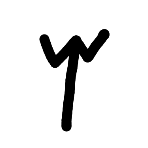

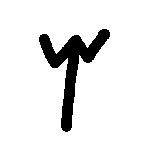

In [4]:
# A higher value means more black-ish (non background) pixels are used.
binary_treshhold = 0.99

display(imgs['img'][0])
imgs['img'] = imgs['img'].apply(lambda img: img > binary_treshhold)
display(imgs['img'][0])

#### Remove empty images and fully black images.

The dataset includes a number of fully black or empty images. This data would cause problems in preprocessing from their extreme values and are removed

In [5]:
imgs = imgs[imgs['img'].apply(lambda x: not np.all(x > 0.99) and not np.all(x < 0.01))]
# Make indexes sequential again.
imgs.reset_index(drop=True, inplace=True)


#### Expand the black in the images
This helps fill small accidental gaps between black strokes that would otherwise create 2 labels for 1 object. 

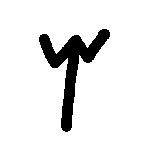

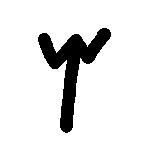

In [6]:
thickening_strength = 1

display(imgs['img'][0])
imgs['img'] = imgs['img'].apply(lambda img: morphology.binary_erosion(img, morphology.disk(thickening_strength)))
display(imgs['img'][0])

#### Create image labels

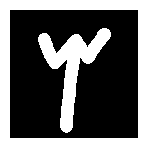

In [7]:
# 1: horizontal and vertical
# 2: 1 and diagonal
connectivity = 2

# Label background as 1 so it sees white as the background and black as the objects.
imgs['img_label'] = imgs['img'].apply(lambda img: measure.label(img, background=1, connectivity=connectivity))

# Combine all labels into one. As all hieroglyphs are connected, multiple labels would only make things harder and more confusing.
imgs['img_label'] = imgs['img_label'].apply(lambda img_label: (img_label > 0).astype(int))

display(imgs['img_label'][0])

#### Get label regions

In [8]:
# Since each image only has one label, we can just take the first/only region.
imgs['region'] = imgs['img_label'].apply(lambda img_label: measure.regionprops(img_label)[0])
imgs['region'][0].convex_area

4458.0

## Create features

#### Create feature dictionary
The keys in this will be the columns of the final features dataframe.

In [9]:
feature_dict = defaultdict(list)

#### Region features

In [10]:
feature_dict = defaultdict(list)

for region in imgs['region']:
    feature_dict['area'].append(region.area)

    feature_dict['width'].append(region.bbox[3] - region.bbox[1])
    feature_dict['height'].append(region.bbox[2] - region.bbox[0])

    feature_dict['hole_count'].append(1 - region.euler_number)

    # Center of mass.
    feature_dict['centroid_x'].append(region.centroid[0])
    feature_dict['centroid_y'].append(region.centroid[1])

    # Density of pixels in the bounding box.
    feature_dict['extent'].append(region.extent)

    # The area of the convex hull.
    feature_dict['convex_area'].append(region.convex_area)

    # Density of pixels in the convex hull. Similar to extent. Indicates how much of the object’s perimeter is concave or irregular.
    feature_dict['solidity'].append(region.solidity)

    # How much the object deviates from a perfect circle.
    feature_dict['eccentricity'].append(region.eccentricity)

    # The tilt.
    feature_dict['orientation'].append(region.orientation)

    # Perimeter of the object. A larger perimeter means a more complex shape.
    feature_dict['perimeter'].append(region.perimeter)

    # Hu moments, which are summaries of the pixel intensity distribution. 
    # They give information about the shape that is invariant to image transformation.
    feature_dict['hu_1'].append(region.moments_hu[0])
    feature_dict['hu_2'].append(region.moments_hu[1])
    feature_dict['hu_3'].append(region.moments_hu[2])
    feature_dict['hu_4'].append(region.moments_hu[3])
    feature_dict['hu_5'].append(region.moments_hu[4])
    feature_dict['hu_6'].append(region.moments_hu[5])
    feature_dict['hu_7'].append(region.moments_hu[6])

feature_dict['area'][:5]

[2394.0, 2354.0, 2485.0, 2242.0, 2968.0]

### Custom features

#### Top-bottom pixel ratio
The difference in pixels between the top half and the bottom half of the image.
Some hieroglyphs have a lot at the top and some are more distributed throughout the shape.

Close to 0 means it's balance. High positive number means it's denser at the top. High negative means it's denser at the bottom.

In [11]:
for img in imgs['img']:
    half_height = img.shape[0] // 2

    top = img[:half_height]
    bottom = img[half_height:]

    top_pixel_count = np.sum(top == False)
    bottom_pixel_count = np.sum(bottom == False)

    feature_dict['top_bottom_ratio'].append(top_pixel_count - bottom_pixel_count)

feature_dict['top_bottom_ratio'][:5]

[940, 834, 997, 888, 1696]

#### Height to width ratio

In images where the drawing is smaller or larger than usual, the base height or width of the symbol may not have as much meaning. In this case, height to width ratio can give a good indication of the shape.

In this ratio, 1 means an equal height and width, over 1 means higher than wide, under 1 means wider than high.

In [12]:
for image in imgs['region']:
    feature_dict['height_width_ratio'].append((image.bbox[2] - image.bbox[0]) / (image.bbox[3] - image.bbox[1]))

feature_dict['height_width_ratio'][:5]

[1.4383561643835616,
 1.394736842105263,
 1.4935064935064934,
 1.703125,
 1.0288461538461537]

#### Create the features dataframe

In [13]:
features = pd.DataFrame(feature_dict)
features['label'] = imgs['label']

features.iloc[:5]

,area,width,height,hole_count,centroid_x,centroid_y,extent,convex_area,solidity,eccentricity,...,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,hu_7,top_bottom_ratio,height_width_ratio,label
0,2394.0,73,105,0,55.979114,61.249791,0.312329,4458.0,0.537012,0.826249,...,0.412100,0.045611,0.077277,0.011199,0.000318,0.002097,-0.000085,940,1.438356,earth
1,2354.0,76,106,0,57.953271,70.215803,0.292205,4644.0,0.506891,0.826489,...,0.438776,0.051799,0.093347,0.012590,0.000430,0.002700,-0.000034,834,1.394737,earth
2,2485.0,77,115,0,51.084507,59.587123,0.280632,5044.0,0.492665,0.865651,...,0.473678,0.080550,0.110401,0.021266,0.001014,0.005548,-0.000185,997,1.493506,earth
3,2242.0,64,109,0,51.552632,64.873327,0.321388,4017.0,0.558128,0.904246,...,0.448572,0.096234,0.079209,0.021492,0.000867,0.006051,-0.000185,888,1.703125,earth
4,2968.0,104,107,1,40.214623,71.681267,0.266715,6465.0,0.459087,0.608811,...,0.420265,0.009140,0.087934,0.006414,0.000151,0.000554,0.000022,1696,1.028846,earth


## Save output

In [ ]:
with open(f'..{os.sep}dataset-numpy{os.sep}features_after_extraction.pkl', 'wb') as f:
    pickle.dump(features, f)